In [ ]:
# Análise Exploratória — Indicador Criança Alfabetizada

**Objetivo desta análise:** entender a estrutura, qualidade e distribuição da base
`features_alunos_ml` (camada Gold, Fase 2) antes de tomar qualquer decisão de
modelagem.

**Contexto da base:** cada linha é um aluno avaliado no 2º ano do Ensino
Fundamental, com proficiência no Saeb, contexto do seu município (taxa de
alfabetização agregada, meta vigente) e o rótulo `label_alfabetizado`
(1 = proficiência ≥ 743 pontos, 0 = caso contrário).

In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)

df = pd.read_parquet("../data/raw/features_alunos_ml.parquet")
df.shape

(3867999, 15)

In [ ]:
## Estrutura e tipos de dados

Antes de qualquer análise de conteúdo, precisamos saber **como** cada coluna
está tipada — isso já revela problemas em potencial (ex.: uma coluna numérica
armazenada como texto, ou um identificador sendo tratado como número).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3867999 entries, 0 to 3867998
Data columns (total 15 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   id_aluno                          object 
 1   ano                               int64  
 2   id_municipio                      object 
 3   nome                              object 
 4   sigla_uf                          object 
 5   nome_regiao                       object 
 6   rede                              object 
 7   rede_label                        object 
 8   serie                             object 
 9   proficiencia                      float64
 10  peso_aluno                        float64
 11  presenca                          object 
 12  taxa_alfabetizacao_municipio      float64
 13  meta_alfabetizacao_municipio_ano  float64
 14  label_alfabetizado                int32  
dtypes: float64(4), int32(1), int64(1), object(9)
memory usage: 427.9+ MB


In [ ]:
## Valores ausentes

Aqui medimos, por coluna, quantos valores estão ausentes em número absoluto e
em percentual do total. Isso vai definir, coluna por coluna, se a estratégia
certa é imputar, descartar a linha, ou descartar a coluna inteira (uma coluna
90% vazia não deveria ser imputada — deveria ser removida).

In [4]:
faltantes = df.isnull().sum().sort_values(ascending=False)
faltantes_pct = (faltantes / len(df) * 100).round(2)
pd.DataFrame({"faltantes": faltantes, "pct": faltantes_pct})

,faltantes,pct
meta_alfabetizacao_municipio_ano,1868546,48.31
proficiencia,513338,13.27
peso_aluno,513338,13.27
taxa_alfabetizacao_municipio,172460,4.46
id_aluno,0,0.00
ano,0,0.00
id_municipio,0,0.00
nome,0,0.00
sigla_uf,0,0.00
nome_regiao,0,0.00


In [5]:
df["label_alfabetizado"].value_counts()

label_alfabetizado
1    1984546
0    1883453
Name: count, dtype: int64

In [6]:
# Cruza com a regra oficial: quem tem proficiência >= 743 deveria ter label=1
pd.crosstab(df["proficiencia"] >= 743, df["label_alfabetizado"])

label_alfabetizado,0,1
proficiencia,,
False,1883453,0
True,0,1984546


In [ ]:
### Conclusão final e decisão de escopo

Com o rótulo corrigido, o padrão faz sentido: **100% dos alunos ausentes**
têm `label_alfabetizado = 0` — coerente com a própria definição da fonte
(não avaliado não pode ser considerado alfabetizado). Entre os alunos
**presentes**, a divisão é real: 59,14% alfabetizados vs. 40,86% não
alfabetizados — sem desbalanceamento severo, mas longe de ser 50/50.

**Decisão de escopo:** vamos restringir a modelagem aos alunos com
`presenca == 1`. Incluir os ausentes ensinaria o modelo a reaprender uma
regra determinística da própria fonte (ausência → não alfabetizado), não
um padrão preditivo real a partir de variáveis educacionais, territoriais
e socioeconômicas — que é exatamente o que o desafio pede. Essa é também a
primeira decisão concreta de **tratamento de data leakage** do projeto:
excluir uma variável (`presenca`) cujo valor 0 determina o rótulo por
construção, não por relação causal a ser aprendida.

In [ ]:
## Filtrando o escopo de modelagem

Aplicamos a decisão anterior: só alunos com `presenca == 1` entram no
conjunto que vai alimentar o modelo. Criamos `df_model` como uma cópia
separada — mantemos `df` intacto (com todo mundo) caso precisemos voltar
a ele pra alguma análise de contexto mais ampla.

In [9]:
df_model = df[df["presenca"] == 1].copy()
print("Linhas antes:", len(df))
print("Linhas depois do filtro:", len(df_model))
df_model["label_alfabetizado"].value_counts(normalize=True).round(4)

Linhas antes: 3867999
Linhas depois do filtro: 0


Series([], Name: proportion, dtype: float64)

In [12]:
df_model = df[df["presenca"] == "1"].copy()
len(df_model)

3355846

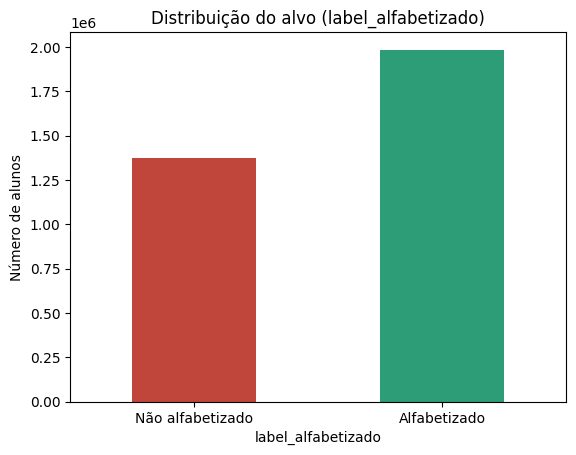

In [13]:
import matplotlib.pyplot as plt

contagem = df_model["label_alfabetizado"].value_counts().sort_index()
contagem.plot(kind="bar", color=["#C0453A", "#2D9D78"])
plt.xticks([0, 1], ["Não alfabetizado", "Alfabetizado"], rotation=0)
plt.ylabel("Número de alunos")
plt.title("Distribuição do alvo (label_alfabetizado)")
plt.show()

In [ ]:
## Investigação: `taxa_alfabetizacao_municipio` é uma fonte de data leakage?

Essa coluna é uma média agregada por (ano, município), calculada a partir
dos mesmos alunos que estamos tentando classificar — incluindo, para cada
linha, o próprio aluno daquela linha. Isso é diferente do vazamento do
`presenca`/`proficiencia` (que é direto e determinístico): aqui o risco
depende do **tamanho da amostra** de cada município. Num município com
3.000 alunos avaliados, o resultado de 1 aluno é irrelevante pra média. Num
município com 5 alunos avaliados, o resultado de 1 aluno pode mudar a média
em até 20 pontos percentuais — a "informação do território" vira, na
prática, quase uma paráfrase do próprio rótulo.

Vamos quantificar quantos municípios têm amostras pequenas antes de decidir
o que fazer.

In [14]:
alunos_por_municipio = (
    df_model.groupby(["ano", "id_municipio"])
    .size()
    .reset_index(name="n_alunos_avaliados")
)
alunos_por_municipio["n_alunos_avaliados"].describe()

count    10388.00000
mean       323.05025
std       1409.51545
min          7.00000
25%         54.00000
50%        112.00000
75%        249.00000
max      94385.00000
Name: n_alunos_avaliados, dtype: float64

In [15]:
# Quantos municípios (por ano) têm amostra pequena o suficiente pra um
# único aluno influenciar significativamente a média do próprio município?
for limite in [5, 10, 30, 50]:
    pct = (alunos_por_municipio["n_alunos_avaliados"] <= limite).mean() * 100
    print(f"Municípios com <= {limite} alunos avaliados: {pct:.1f}%")

Municípios com <= 5 alunos avaliados: 0.0%
Municípios com <= 10 alunos avaliados: 0.3%
Municípios com <= 30 alunos avaliados: 9.8%
Municípios com <= 50 alunos avaliados: 23.1%


In [ ]:
### Conclusão e decisão de tratamento

`taxa_alfabetizacao_municipio` é uma agregação legítima de contexto
territorial, mas ~10% dos municípios têm amostra pequena o suficiente
(≤30 alunos avaliados) para que o resultado de um único aluno influencie
de forma não desprezível a própria média usada para prevê-lo.

**Decisão:** em vez de descartar a variável (ela é exatamente o tipo de
dado territorial que o desafio pede para incluir), o split treino/teste
será feito **por município** (`GroupShuffleSplit`/`GroupKFold` por
`id_municipio`), não por aluno. Isso garante que nenhum município a## Distribuições territoriais e temporais

Olhamos rede, região, UF e ano — tanto pra entender a composição da base
quanto pra confirmar que não há uma classe dominando tanto a ponto de
inviabilizar alguma fatia da análise (ex.: uma região com poucos dados).pareça
simultaneamente em treino e teste — eliminando o caminho pelo qual esse
vazamento sutil poderia inflar artificialmente a métrica de generalização.
Essa decisão será aplicada na etapa de split.

In [16]:
print(df_model["ano"].value_counts())
print()
print(df_model["rede_label"].value_counts())
print()
print(df_model["nome_regiao"].value_counts())

ano
2024    1852788
2023    1503058
Name: count, dtype: int64

rede_label
Municipal    2983123
Estadual      372699
Privada           24
Name: count, dtype: int64

nome_regiao
Sudeste         1107474
Nordeste         969030
Sul              577249
Norte            368708
Centro-Oeste     333385
Name: count, dtype: int64


In [ ]:
## A lacuna de `meta_alfabetizacao_municipio_ano` é estrutural, não aleatória

Vimos no início que essa coluna falta em 48% das linhas. A hipótese é que
isso é 100% explicado pelo ano: só existem metas para 2024-2030, então
2023 (ano-base, antes do compromisso começar a valer) nunca deveria ter
meta. Confirmamos cruzando ausência da meta com o ano.

In [17]:
pd.crosstab(df_model["ano"], df_model["meta_alfabetizacao_municipio_ano"].isnull())

meta_alfabetizacao_municipio_ano,False,True
ano,,
2023,0,1503058
2024,1766270,86518


In [18]:
pd.crosstab(df_model[df_model["ano"] == 2024]["rede_label"], df_model[df_model["ano"] == 2024]["meta_alfabetizacao_municipio_ano"].isnull())

meta_alfabetizacao_municipio_ano,False,True
rede_label,,
Estadual,196833,44340
Municipal,1569413,42178
Privada,24,0


In [ ]:
### Conclusão: lacuna tem duas causas, ambas estruturais

1. **100% de 2023** falta meta — não existia meta antes de 2024 (esperado).
2. **~4,7% de 2024** falta meta (86.518 linhas) — não é explicado só pela
   rede do aluno (Estadual falta ~18%, Municipal falta ~2,6%, ambos > 0).
   A causa mais provável: o join é feito por `(ano, id_municipio)`, não por
   rede — então a lacuna real é de **municípios inteiros** sem meta
   municipal registrada naquele ano, afetando todos os alunos de lá,
   independente da própria rede.

**Decisão de tratamento:** essa é uma ausência estrutural, não aleatória,
mas também não é vazamento — é cobertura incompleta da fonte. Trataremos
com imputação (mediana) **mais uma coluna indicadora binária**
(`meta_ausente`), prática recomendada quando a própria ausência carrega
informação (município sem meta pode ser, em si, um sinal territorial
relevante) — em vez de simplesmente preencher e esconder o padrão.

In [ ]:
## Hipótese 1: proficiência se distribui de forma clara em torno do corte

Visualizar a distribuição da proficiência ajuda a checar se o corte de 743
pontos cai numa região "decisiva" da curva (onde pequenas variações mudam
o rótulo) ou numa região de baixa densidade (onde o rótulo é mais estável).
Isso importa pra entender o quão "difícil" é a fronteira de decisão que o
modelo vai ter que aprender.

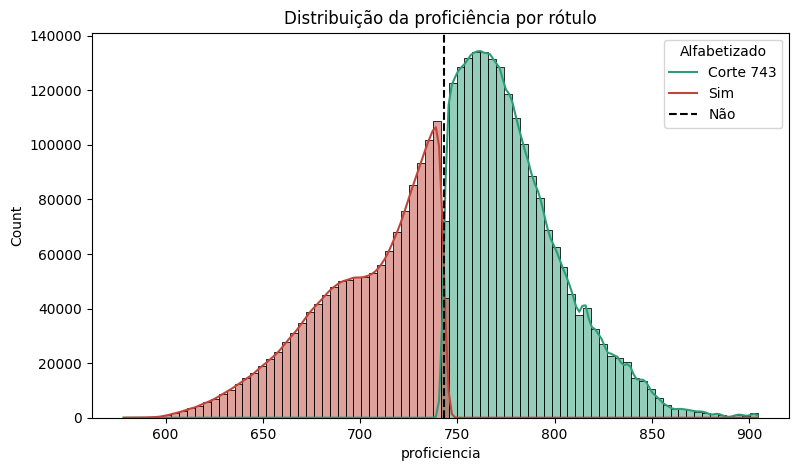

count    3.354661e+06
mean     7.483799e+02
std      4.758598e+01
min      5.784600e+02
25%      7.197686e+02
50%      7.531500e+02
75%      7.796500e+02
max      9.043820e+02
Name: proficiencia, dtype: float64

In [19]:
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(data=df_model, x="proficiencia", hue="label_alfabetizado", bins=80, kde=True, palette=["#C0453A", "#2D9D78"])
plt.axvline(743, color="black", linestyle="--", label="Corte oficial (743)")
plt.legend(title="Alfabetizado", labels=["Corte 743", "Sim", "Não"])
plt.title("Distribuição da proficiência por rótulo")
plt.show()

df_model["proficiencia"].describe()

In [ ]:
## Hipótese 2: existe desigualdade regional na taxa de alfabetização

Pergunta de negócio direta do desafio: "quais regiões possuem padrões
semelhantes?" e "quais municípios apresentam maior risco educacional?".
Começamos no nível mais agregado (região) e depois descemos pra UF.

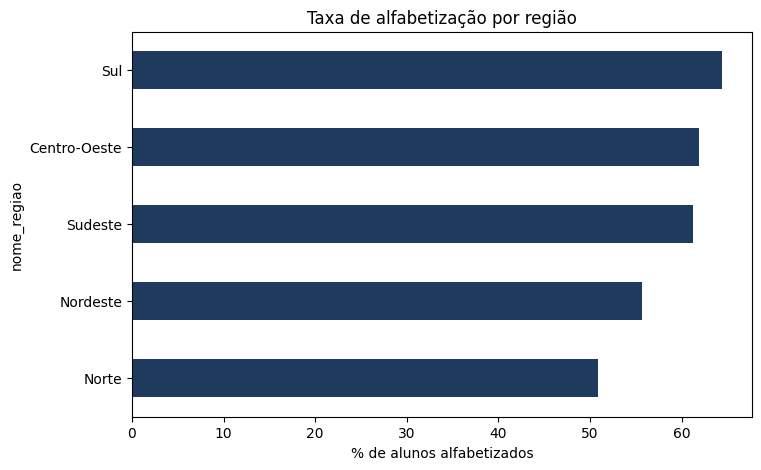

nome_regiao
Norte           50.93
Nordeste        55.72
Sudeste         61.25
Centro-Oeste    61.91
Sul             64.45
Name: label_alfabetizado, dtype: float64

In [20]:
taxa_por_regiao = df_model.groupby("nome_regiao")["label_alfabetizado"].mean().sort_values() * 100

plt.figure(figsize=(8, 5))
taxa_por_regiao.plot(kind="barh", color="#1E3A5F")
plt.xlabel("% de alunos alfabetizados")
plt.title("Taxa de alfabetização por região")
plt.show()

taxa_por_regiao.round(2)

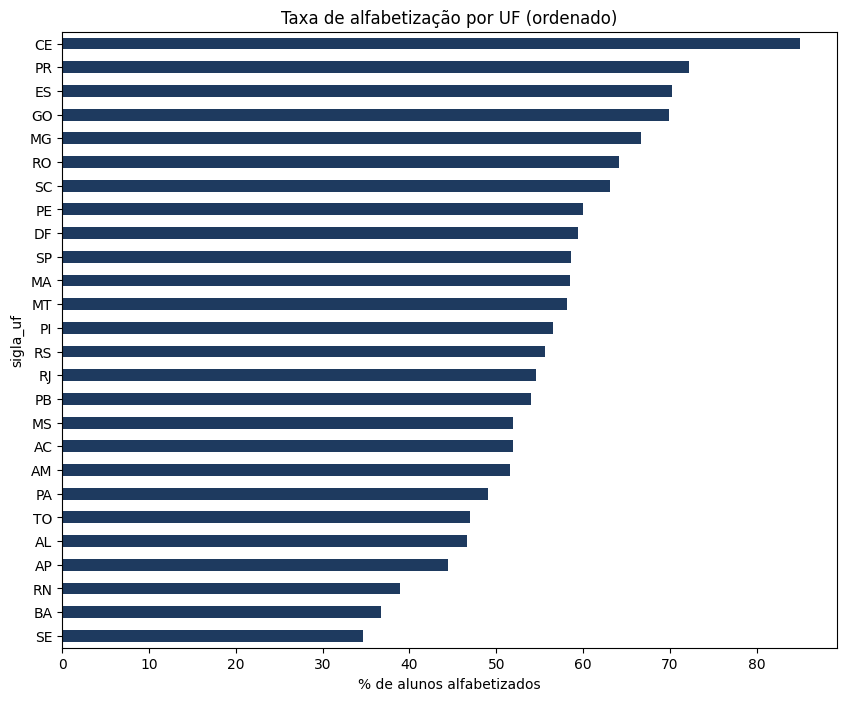

5 piores UFs:
sigla_uf
SE    34.63
BA    36.70
RN    38.93
AP    44.47
AL    46.67
Name: label_alfabetizado, dtype: float64

5 melhores UFs:
sigla_uf
MG    66.62
GO    69.84
ES    70.19
PR    72.22
CE    85.01
Name: label_alfabetizado, dtype: float64


In [21]:
taxa_por_uf = df_model.groupby("sigla_uf")["label_alfabetizado"].mean().sort_values() * 100

plt.figure(figsize=(10, 8))
taxa_por_uf.plot(kind="barh", color="#1E3A5F")
plt.xlabel("% de alunos alfabetizados")
plt.title("Taxa de alfabetização por UF (ordenado)")
plt.show()

print("5 piores UFs:")
print(taxa_por_uf.head(5).round(2))
print("\n5 melhores UFs:")
print(taxa_por_uf.tail(5).round(2))

In [ ]:
## Hipótese 3: a rede de ensino e o ano influenciam a taxa de alfabetização

`rede_label` (Municipal/Estadual/Privada) e `ano` (2023/2024) são variáveis
categóricas simples de checar e podem revelar se a política pública está
avançando ao longo do tempo, e se algum tipo de rede tem desempenho
sistematicamente diferente.

In [22]:
print("Por rede:")
print((df_model.groupby("rede_label")["label_alfabetizado"].mean() * 100).round(2))
print("\nPor ano:")
print((df_model.groupby("ano")["label_alfabetizado"].mean() * 100).round(2))

Por rede:
rede_label
Estadual     62.09
Municipal    58.77
Privada      66.67
Name: label_alfabetizado, dtype: float64

Por ano:
ano
2023    58.38
2024    59.75
Name: label_alfabetizado, dtype: float64


In [ ]:
## Hipótese 4: o contexto territorial (`taxa_alfabetizacao_municipio`) se relaciona com o resultado individual

Já discutimos o risco de vazamento dessa variável — mas ela só vale a pena
manter no modelo se, de fato, carregar sinal preditivo real. Um boxplot
comparando a distribuição da taxa municipal entre alunos alfabetizados e
não-alfabetizados confirma (ou não) essa relação.

/var/folders/fc/ybf4nj2j5m33fvm6f_qzsfhh0000gn/T/ipykernel_44172/3727435957.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="label_alfabetizado", y="taxa_alfabetizacao_municipio", palette=["#C0453A", "#2D9D78"])


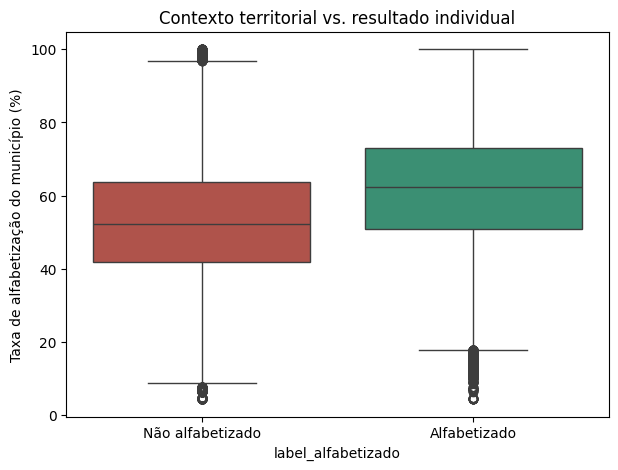

,count,mean,std,min,25%,50%,75%,max
label_alfabetizado,,,,,,,,
0,1312736.0,52.716472,14.932037,4.4,41.8,52.3,63.80,100.0
1,1922252.0,62.489636,16.408621,4.4,50.9,62.4,72.99,100.0


In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_model, x="label_alfabetizado", y="taxa_alfabetizacao_municipio", palette=["#C0453A", "#2D9D78"])
plt.xticks([0, 1], ["Não alfabetizado", "Alfabetizado"])
plt.ylabel("Taxa de alfabetização do município (%)")
plt.title("Contexto territorial vs. resultado individual")
plt.show()

df_model.groupby("label_alfabetizado")["taxa_alfabetizacao_municipio"].describe()

In [ ]:
## Síntese das hipóteses investigadas

| # | Hipótese | Resultado |
|---|---|---|
| 1 | O corte de 743 cai numa região densa da distribuição | Confirmado — média (748,4) e mediana (753,2) muito próximas do corte, desvio padrão 47,6. Fronteira de decisão genuinamente difícil. |
| 2 | Existe desigualdade regional | Confirmado — 13,5 p.p. entre Norte (50,9%) e Sul (64,5%). |
| 2b | UF é mais informativo que região | Confirmado — 50,4 p.p. entre a pior (SE, 34,6%) e a melhor (CE, 85,0%) UF. Ceará é um outlier positivo dentro do Nordeste (Paic), mostrando que agregação por região esconde heterogeneidade real. |
| 3 | Rede e ano influenciam o resultado | Confirmado parcialmente — Estadual > Municipal (62,1% vs. 58,8%); Privada tem amostra pequena demais (n=24) pra ser confiável. Melhora nacional de +1,37 p.p. entre 2023 e 2024 — ritmo insuficiente pra meta de 2030. |
| 4 | Contexto territorial se relaciona com resultado individual | Confirmado — municípios com maior taxa de alfabetização têm alunos individualmente mais propensos a estarem alfabetizados (62,5% vs. 52,7% de taxa média entre os grupos). Variável mantida, com split por município para mitigar vazamento. |

Essas conclusões orientam diretamente a etapa de engenharia de atributos: manter
`sigla_uf` (mais informativo que `nome_regiao`), `rede_label` (agrupando ou
descartando "Privada" por amostra insuficiente), `ano`, `taxa_alfabetizacao_municipio`
e `meta_alfabetizacao_municipio_ano` (com indicador de ausência) como
variáveis preditoras — excluindo `proficiencia` e `presenca` por vazamento
direto, já decidido anteriormente.